# 02 — Unsupervised Learning: K-means-QLDE Customer Segmentation

**Referensi Paper:**  
Wang, G. (2025). *Customer segmentation in the digital marketing using a Q-learning based differential evolution algorithm integrated with K-means clustering.* PLoS ONE 20(2): e0318519. https://doi.org/10.1371/journal.pone.0318519

---

## Ringkasan Metode (Section 3 Paper)

Paper ini mengusulkan framework **K-means-QLDE** — sebuah metode customer segmentation yang menggabungkan:

1. **PCA** (Section 3.1) — reduksi dimensi dari 11 fitur RFM, memilih 6 komponen utama yang menjelaskan ≥90% variance
2. **K-means** (Section 3.2) — clustering dasar dengan minimisasi SSE (Sum of Squared Errors)
3. **QLDE — Q-Learning based Differential Evolution** (Section 3.3) — optimasi adaptif K-means menggunakan:
   - Inisialisasi populasi chaotic (Logistic mapping)
   - Mutasi cluster-guided (top 50% individu terbaik)
   - Crossover dan seleksi klasik DE
   - Q-learning untuk adaptasi scaling factor F secara otomatis
4. **Elbow method** (Section 4.2) — menentukan jumlah cluster optimal K=6

---

## Alur Kerja Notebook Ini

```
Data PCA (6 PC)  →  Elbow Method  →  K-means-QLDE  →  Visualisasi  →  Analisis Cluster
       ↑                                                                      ↓
  [Notebook 01]                                              [Space untuk Algoritma Pembanding]
```

> **Catatan:** Notebook ini menggunakan output dari `01_eda_and_preprocessing.ipynb`:
> - `data/processed/customer_features_pca.csv` — fitur setelah PCA (6 komponen)
> - `data/processed/customer_features_scaled.csv` — fitur setelah Z-score normalisasi (11 fitur)

In [27]:
# ============================================================
# Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set random seed untuk reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Konfigurasi visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Palet warna untuk 6 cluster
CLUSTER_COLORS = ['#E63946', '#2A9D8F', '#E9C46A', '#264653', '#F4A261', '#A8DADC']
CLUSTER_LABELS = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']

print('Libraries berhasil diimport.')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries berhasil diimport.
NumPy  : 2.4.6
Pandas : 3.0.3


## 1. Load Data Preprocessed

Memuat data hasil preprocessing dari Notebook 01:
- **`customer_features_pca.csv`** — 6 principal components (≥90% variance, sesuai Section 4.1 paper)
- **`customer_features_scaled.csv`** — 11 fitur ternormalisasi (untuk analisis cluster centers)

In [28]:
# ============================================================
# Load Data
# ============================================================
df_pca    = pd.read_csv('../data/processed/customer_features_pca.csv', index_col='CustomerID')
df_scaled = pd.read_csv('../data/processed/customer_features_scaled.csv', index_col='CustomerID')
df_raw    = pd.read_csv('../data/processed/customer_features_raw.csv', index_col='CustomerID')

print(f'Data PCA (6 PC)       : {df_pca.shape}    — kolom: {list(df_pca.columns)}')
print(f'Data Scaled (11 fitur): {df_scaled.shape} — kolom: {list(df_scaled.columns)}')
print(f'Data Raw (11 fitur)   : {df_raw.shape}    — kolom: {list(df_raw.columns)}')
print(f'\nJumlah pelanggan: {len(df_pca):,}')

# Array numpy untuk komputasi
X_pca    = df_pca.values       # shape: (4335, 6)
X_scaled = df_scaled.values    # shape: (4335, 11)
X_raw    = df_raw.values       # shape: (4335, 11)

print(f'\nX_pca shape   : {X_pca.shape}')
print(f'X_scaled shape: {X_scaled.shape}')

Data PCA (6 PC)       : (4335, 6)    — kolom: ['PCA 1', 'PCA 2', 'PCA 3', 'PCA 4', 'PCA 5', 'PCA 6']
Data Scaled (11 fitur): (4335, 11) — kolom: ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11']
Data Raw (11 fitur)   : (4335, 11)    — kolom: ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8', 'Var9', 'Var10', 'Var11']

Jumlah pelanggan: 4,335

X_pca shape   : (4335, 6)
X_scaled shape: (4335, 11)


## 2. Elbow Method — Menentukan Jumlah Cluster Optimal (Section 4.2 Paper)

Paper menggunakan **elbow method** untuk menentukan K optimal. Dari Fig 9 pada paper:
- Saat K = 6, terjadi **titik infleksi (elbow)** yang jelas pada kurva SSE
- K = 6 dipilih sebagai jumlah cluster optimal

**SSE (Sum of Squared Errors):**
$$\text{SSE} = \sum_{l=1}^{K} \sum_{C(i)=l} \|x_i - m_l\|^2 \quad \text{(Persamaan 2)}$$

  K= 2 → SSE=   34,178.85 | Silhouette=0.8909
  K= 3 → SSE=   27,680.01 | Silhouette=0.3384
  K= 4 → SSE=   22,566.50 | Silhouette=0.3427
  K= 5 → SSE=   18,906.91 | Silhouette=0.3873
  K= 6 → SSE=   15,658.67 | Silhouette=0.4261
  K= 7 → SSE=   12,750.73 | Silhouette=0.4498
  K= 8 → SSE=   10,828.19 | Silhouette=0.4507
  K= 9 → SSE=    9,505.00 | Silhouette=0.4491
  K=10 → SSE=    8,558.87 | Silhouette=0.3751
  K=11 → SSE=    8,011.02 | Silhouette=0.3570
  K=12 → SSE=    7,309.05 | Silhouette=0.3702


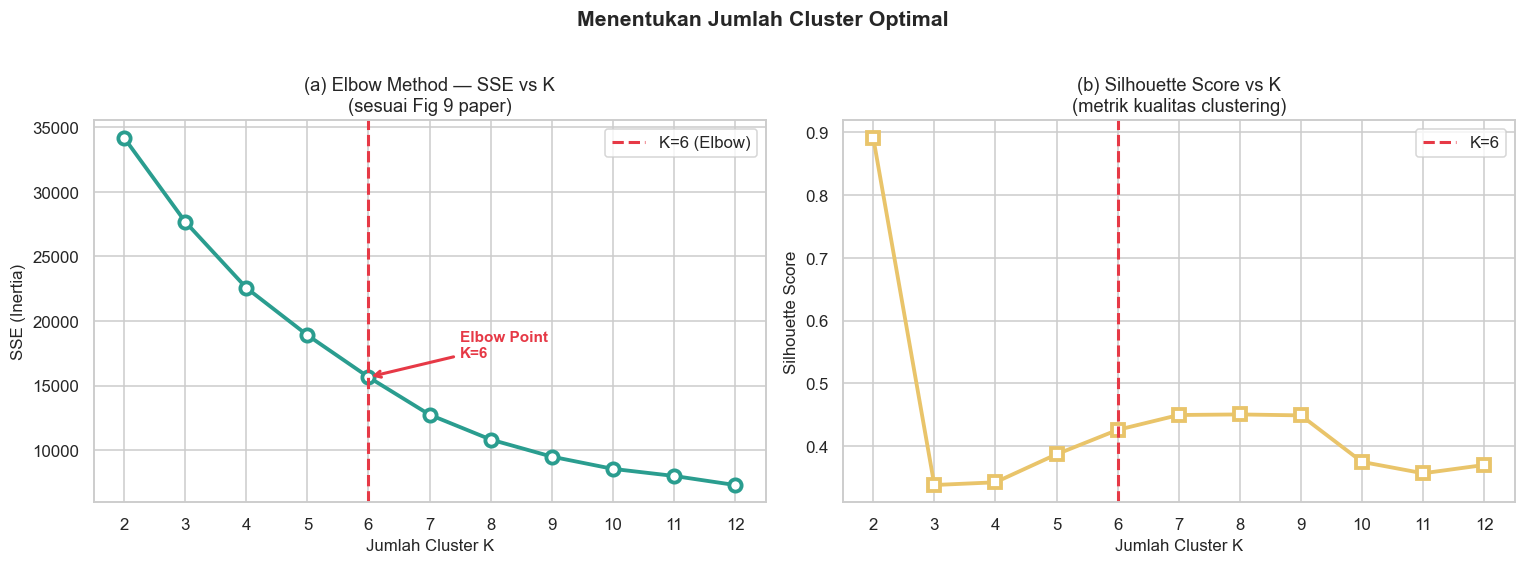


K=6 dipilih: SSE=15,658.67 | Silhouette=0.4261


In [29]:
# ============================================================
# Elbow Method — menghitung SSE untuk K = 2..12
# (menggunakan X_pca sesuai Section 4.2 paper)
# ============================================================
K_range = range(2, 13)
sse_list = []
sil_list = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_SEED)
    km.fit(X_pca)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_pca, km.labels_))
    print(f'  K={k:2d} → SSE={km.inertia_:>12,.2f} | Silhouette={sil_list[-1]:.4f}')

# ──── Visualisasi ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold', y=1.02)

# Panel kiri: Elbow (SSE)
ax = axes[0]
ax.plot(list(K_range), sse_list, marker='o', color='#2A9D8F', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.axvline(x=6, color='#E63946', linestyle='--', linewidth=2, label='K=6 (Elbow)')
ax.set_title('(a) Elbow Method — SSE vs K\n(sesuai Fig 9 paper)', fontsize=12)
ax.set_xlabel('Jumlah Cluster K')
ax.set_ylabel('SSE (Inertia)')
ax.legend()
ax.set_xticks(list(K_range))

# Annotasi titik elbow
ax.annotate('Elbow Point\nK=6', xy=(6, sse_list[4]), xytext=(7.5, sse_list[4]*1.1),
            arrowprops=dict(arrowstyle='->', color='#E63946', lw=2),
            fontsize=10, color='#E63946', fontweight='bold')

# Panel kanan: Silhouette Score
ax = axes[1]
ax.plot(list(K_range), sil_list, marker='s', color='#E9C46A', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.axvline(x=6, color='#E63946', linestyle='--', linewidth=2, label='K=6')
ax.set_title('(b) Silhouette Score vs K\n(metrik kualitas clustering)', fontsize=12)
ax.set_xlabel('Jumlah Cluster K')
ax.set_ylabel('Silhouette Score')
ax.legend()
ax.set_xticks(list(K_range))

plt.tight_layout()
plt.savefig('../models/elbow_method.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\nK=6 dipilih: SSE={sse_list[4]:,.2f} | Silhouette={sil_list[4]:.4f}')

## 3. Algoritma QLDE — Q-Learning Based Differential Evolution

Ini adalah **inti kontribusi paper**. QLDE mengoptimasi inisialisasi cluster center K-means.

### 3.1 Differential Evolution (DE) — Konsep Dasar

DE terdiri dari 4 proses:
1. **Inisialisasi** menggunakan Logistic Chaotic Mapping (Persamaan 4–5)
2. **Mutasi cluster-guided** (Persamaan 6) — top 50% individu terbaik sebagai guiding direction
3. **Crossover** (Persamaan 7) — pertukaran informasi
4. **Seleksi** (Persamaan 8) — survival of the fittest

### 3.2 Q-Learning untuk Adaptasi Scaling Factor F

- Setiap individu memiliki scaling factor F tersendiri
- Q-learning mengupdate F dengan adjustment λ ∈ {-0.01, 0, 0.01}
- Reward R=1 jika fitness trial > parent, R=0 jika tidak
- Update Q-table: $Q(s_t, a_t) = Q(s_t, a_t) + \alpha[r_{t+1} + \gamma \cdot \text{expQ} - Q(s_t, a_t)]$ (Persamaan 10–11)
- Action selection menggunakan Softmax strategy (Persamaan 12)

In [ ]:
# ============================================================
# Implementasi Algoritma QLDE
# Wang, G. (2025) — Section 3.3
# ============================================================

class QLDE:
    """
    Q-Learning based Differential Evolution (QLDE) Algorithm
    
    Mengoptimasi inisialisasi cluster center K-means dengan meminimalkan SSE.
    Diimplementasikan sesuai Section 3.3 paper Wang (2025).
    
    Parameters
    ----------
    n_clusters : int
        Jumlah cluster K (K=6 sesuai paper)
    pop_size : int
        Ukuran populasi DE
    max_iter : int
        Jumlah iterasi maksimum
    F_init : float
        Scaling factor awal DE (mengikuti update Q-learning)
    Cr : float
        Crossover rate
    mu : float
        Parameter kontrol Logistic Chaotic Mapping (biasanya [3.57, 4])
    alpha : float
        Learning rate Q-learning
    gamma : float
        Discount factor Q-learning
    epsilon : float
        Greedy threshold untuk dynamic ε-greedy strategy
    random_state : int
        Random seed
    """
    
    def __init__(self, n_clusters=6, pop_size=30, max_iter=100,
                 F_init=0.5, Cr=0.9, mu=3.9,
                 alpha=0.1, gamma=0.9, epsilon=0.2,
                 random_state=42):
        self.n_clusters   = n_clusters
        self.pop_size     = pop_size
        self.max_iter     = max_iter
        self.F_init       = F_init
        self.Cr           = Cr
        self.mu           = mu
        self.alpha        = alpha
        self.gamma        = gamma
        self.epsilon      = epsilon
        self.random_state = random_state
        
        # Q-learning: 3 actions λ ∈ {-0.01, 0, 0.01}
        self.actions = np.array([-0.01, 0.0, 0.01])
        # 2 states: S=1 (fitness membaik), S=2 (fitness tidak membaik)
        self.n_states = 2
        self.n_actions = len(self.actions)
        
    def _logistic_chaotic(self, n, d):
        """
        Inisialisasi populasi menggunakan Logistic Chaotic Mapping.
        Persamaan (4): ϕ_{j+1} = μ * ϕ_j * (1 - ϕ_j)
        Persamaan (5): z^k_{ij} = LB_j + ϕ_j * (UB_j - LB_j)
        """
        np.random.seed(self.random_state)
        phi = np.random.rand(d)  # ϕ_0 ∈ (0,1)
        pop = np.zeros((n, d))
        for i in range(n):
            phi = self.mu * phi * (1 - phi)  # Logistic map
            pop[i] = phi
        return pop
    
    def _fitness(self, centers, X):
        """
        Fitness function = SSE
        Menghitung total jarak kuadrat dari setiap data ke centroid DE terdekat.
        """
        # Ubah bentuk array (n_clusters, n_features)
        centers_reshaped = centers.reshape(self.n_clusters, -1)
        
        # Hitung jarak setiap titik data (X) ke semua kandidat centroid
        dists = np.linalg.norm(X[:, np.newaxis, :] - centers_reshaped[np.newaxis, :, :], axis=2)
        
        # Ambil jarak terdekat (minimum) untuk setiap titik data
        min_dists = np.min(dists, axis=1)
        
        # Kuadratkan dan jumlahkan (inilah nilai SSE murni untuk K-Means)
        sse = np.sum(min_dists ** 2)
        
        return sse
    
    def _softmax(self, q_values):
        """
        Softmax strategy untuk action selection.
        Persamaan (12): π(s_i, a_j) = exp[Q(s_i, a_j)] / Σ_j exp[Q(s_i, a_j)]
        """
        q_exp = np.exp(q_values - np.max(q_values))  # numerically stable
        return q_exp / q_exp.sum()
    
    def _q_learning_action(self, Q_table, state, k, k_max):
        """
        Pilih action menggunakan dynamic ε-greedy strategy.
        Persamaan (10): expQ = max Q(s_{t+1}, a') jika rand < 1 - ε*(k/k_max)
                               rand_choice() jika tidak
        """
        threshold = 1 - self.epsilon * (k / k_max)
        if np.random.rand() < threshold:
            # Pilih berdasarkan Softmax (Persamaan 12)
            probs = self._softmax(Q_table[state])
            action_idx = np.random.choice(self.n_actions, p=probs)
        else:
            # Random exploration
            action_idx = np.random.randint(self.n_actions)
        return action_idx
    
    def fit(self, X):
        """
        Jalankan algoritma K-means-QLDE.
        
        Parameters
        ----------
        X : np.ndarray, shape (n_samples, n_features)
            Data input (PCA features)
        
        Returns
        -------
        self
        """
        n_samples, n_features = X.shape
        dim = self.n_clusters * n_features  # dimensi individu = K * d
        
        # ── Batas bawah dan atas dari data ─────────────────────
        LB = np.tile(X.min(axis=0), self.n_clusters)
        UB = np.tile(X.max(axis=0), self.n_clusters)
        
        # ── Inisialisasi Populasi via Logistic Chaotic (Persamaan 4–5) ──
        pop_phi = self._logistic_chaotic(self.pop_size, dim)  # ϕ ∈ [0,1]
        population = LB + pop_phi * (UB - LB)                 # z^k_ij
        
        # ── Scaling factor per-individu (Persamaan 13) ──────────
        F_arr = np.full(self.pop_size, self.F_init)
        
        # ── Q-table: shape (n_states, n_actions) ────────────────
        # state 0 → S=1 (fitness membaik), state 1 → S=2 (tidak membaik)
        Q_table = np.zeros((self.n_states, self.n_actions))
        
        # ── Hitung fitness awal ──────────────────────────────────
        fitness = np.array([self._fitness(pop, X) for pop in population])
        
        best_idx  = np.argmin(fitness)
        best_sol  = population[best_idx].copy()
        best_fit  = fitness[best_idx]
        
        # Riwayat konvergensi
        self.convergence_curve_ = [best_fit]
        
        # ── Main Loop ───────────────────────────────────────────
        for k in range(1, self.max_iter + 1):
            # Top 50% individu terbaik (cluster-guided mutation)
            sorted_idx = np.argsort(fitness)
            top50_idx  = sorted_idx[:self.pop_size // 2]
            
            for i in range(self.pop_size):
                # ── Mutasi cluster-guided (Persamaan 6) ─────────
                # Lk: dipilih acak dari top 50%
                Lk_idx = np.random.choice(top50_idx)
                # i1, i2: dipilih acak dari seluruh populasi (≠ i, ≠ Lk_idx)
                candidates = [j for j in range(self.pop_size) if j != i and j != Lk_idx]
                i1, i2    = np.random.choice(candidates, size=2, replace=False)
                
                # v^k_i = z^k_{Lk} + F_i * (z^k_{i1} - z^k_{i2})
                v = population[Lk_idx] + F_arr[i] * (population[i1] - population[i2])
                
                # ── Crossover (Persamaan 7) ──────────────────────
                j_rand = np.random.randint(dim)
                r2     = np.random.rand(dim)
                u      = np.where((r2 <= self.Cr) | (np.arange(dim) == j_rand),
                                  v, population[i])
                
                # Clip ke batas domain
                u = np.clip(u, LB, UB)
                
                # ── Seleksi (Persamaan 8) ────────────────────────
                fit_u = self._fitness(u, X)
                fit_z = fitness[i]
                
                if fit_u < fit_z:          # trial lebih baik
                    population[i] = u
                    fitness[i]    = fit_u
                    reward = 1
                    state  = 0             # S=1
                else:
                    reward = 0
                    state  = 1             # S=2
                
                # ── Q-learning Update (Persamaan 10–11) ─────────
                action_idx = self._q_learning_action(Q_table, state, k, self.max_iter)
                lambda_i   = self.actions[action_idx]
                
                # Persamaan (13): F_i = F_i + λ_i
                F_arr[i] = np.clip(F_arr[i] + lambda_i, 0.1, 1.0)
                
                # expQ: Persamaan (10)
                next_state = 0 if reward == 1 else 1
                k_ratio    = k / self.max_iter
                if np.random.rand() < (1 - self.epsilon * k_ratio):
                    exp_Q = np.max(Q_table[next_state])
                else:
                    exp_Q = Q_table[next_state, np.random.randint(self.n_actions)]
                
                # Persamaan (11): Q update
                Q_table[state, action_idx] += self.alpha * (
                    reward + self.gamma * exp_Q - Q_table[state, action_idx]
                )
            
            # Update best solution
            best_idx = np.argmin(fitness)
            if fitness[best_idx] < best_fit:
                best_fit = fitness[best_idx]
                best_sol = population[best_idx].copy()
            
            self.convergence_curve_.append(best_fit)
        
        # ── K-means final dengan optimized centers ───────────────
        init_centers = best_sol.reshape(self.n_clusters, n_features)
        km = KMeans(n_clusters=self.n_clusters, init=init_centers,
                    n_init=1, max_iter=300, random_state=self.random_state)
        km.fit(X)
        
        self.labels_          = km.labels_
        self.cluster_centers_ = km.cluster_centers_
        self.inertia_         = km.inertia_
        self.best_qlde_sse_   = best_fit
        self.Q_table_         = Q_table
        self.F_final_         = F_arr
        
        return self

print('Kelas QLDE berhasil didefinisikan.')
print('\nParameter utama QLDE sesuai paper:')
print('  - Inisialisasi: Logistic Chaotic Mapping (μ=3.9)')
print('  - Mutasi: cluster-guided (top 50% individu terbaik)')
print('  - Q-learning: α=0.1, γ=0.9, ε=0.2')
print('  - Actions λ: {-0.01, 0, 0.01}')
print('  - Reward: R=1 jika fitness membaik, R=0 jika tidak')

Kelas QLDE berhasil didefinisikan.

Parameter utama QLDE sesuai paper:
  - Inisialisasi: Logistic Chaotic Mapping (μ=3.9)
  - Mutasi: cluster-guided (top 50% individu terbaik)
  - Q-learning: α=0.1, γ=0.9, ε=0.2
  - Actions λ: {-0.01, 0, 0.01}
  - Reward: R=1 jika fitness membaik, R=0 jika tidak


## 4. Menjalankan K-means-QLDE (K = 6)

Menjalankan algoritma K-means-QLDE dengan K=6 cluster menggunakan data PCA (6 komponen), sesuai Section 4.2 paper.

In [31]:
# ============================================================
# Jalankan K-means-QLDE dengan K=6
# Sesuai Section 4.2 paper
# ============================================================
import time

K_OPTIMAL = 6  # Sesuai elbow method (Fig 9 paper)

print(f'Menjalankan K-means-QLDE (K={K_OPTIMAL})...')
print(f'Input: X_pca shape = {X_pca.shape}')
print('-' * 50)

t_start = time.time()

qlde = QLDE(
    n_clusters   = K_OPTIMAL,
    pop_size     = 30,        # ukuran populasi
    max_iter     = 100,       # jumlah iterasi
    F_init       = 0.5,       # scaling factor awal
    Cr           = 0.9,       # crossover rate
    mu           = 3.9,       # parameter Logistic map
    alpha        = 0.1,       # learning rate Q-learning
    gamma        = 0.9,       # discount factor
    epsilon      = 0.2,       # greedy threshold
    random_state = RANDOM_SEED
)
qlde.fit(X_pca)

t_elapsed = time.time() - t_start

print(f'\n✓ Selesai dalam {t_elapsed:.1f} detik')
print(f'  SSE QLDE (best)    : {qlde.best_qlde_sse_:,.2f}')
print(f'  SSE K-means final  : {qlde.inertia_:,.2f}')
print(f'\nDistribusi Cluster:')

cluster_counts = pd.Series(qlde.labels_).value_counts().sort_index()
for c, cnt in cluster_counts.items():
    pct = cnt / len(qlde.labels_) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {c+1}: {cnt:4d} pelanggan ({pct:.1f}%)  {bar}')

# Simpan label cluster ke dataframe
df_pca['Cluster']    = qlde.labels_
df_scaled['Cluster'] = qlde.labels_
df_raw['Cluster']    = qlde.labels_

Menjalankan K-means-QLDE (K=6)...
Input: X_pca shape = (4335, 6)
--------------------------------------------------

✓ Selesai dalam 4.9 detik
  SSE QLDE (best)    : 19,621.12
  SSE K-means final  : 17,525.31

Distribusi Cluster:
  Cluster 1: 1314 pelanggan (30.3%)  ███████████████
  Cluster 2: 2622 pelanggan (60.5%)  ██████████████████████████████
  Cluster 3:  384 pelanggan (8.9%)  ████
  Cluster 4:    6 pelanggan (0.1%)  
  Cluster 5:    7 pelanggan (0.2%)  
  Cluster 6:    2 pelanggan (0.0%)  


## 5. Visualisasi Hasil Clustering

### 5.1 Kurva Konvergensi QLDE

Menampilkan bagaimana SSE berkurang seiring iterasi QLDE berjalan.

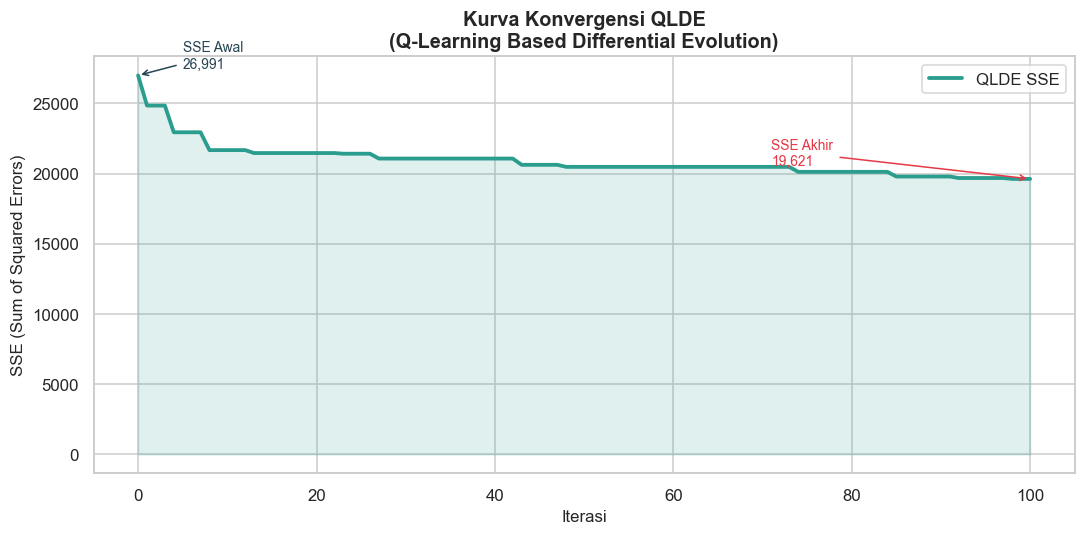

Perbaikan SSE: 27.31%


In [32]:
# ============================================================
# Visualisasi 1: Kurva Konvergensi QLDE
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(qlde.convergence_curve_, color='#2A9D8F', linewidth=2.5, label='QLDE SSE')
ax.fill_between(range(len(qlde.convergence_curve_)),
                qlde.convergence_curve_, alpha=0.15, color='#2A9D8F')

ax.set_title('Kurva Konvergensi QLDE\n(Q-Learning Based Differential Evolution)', fontsize=13, fontweight='bold')
ax.set_xlabel('Iterasi')
ax.set_ylabel('SSE (Sum of Squared Errors)')
ax.legend(fontsize=11)

# Annotasi SSE awal dan akhir
ax.annotate(f'SSE Awal\n{qlde.convergence_curve_[0]:,.0f}',
            xy=(0, qlde.convergence_curve_[0]),
            xytext=(5, qlde.convergence_curve_[0] * 1.02),
            fontsize=9, color='#264653',
            arrowprops=dict(arrowstyle='->', color='#264653'))
ax.annotate(f'SSE Akhir\n{qlde.convergence_curve_[-1]:,.0f}',
            xy=(len(qlde.convergence_curve_)-1, qlde.convergence_curve_[-1]),
            xytext=(len(qlde.convergence_curve_)-30, qlde.convergence_curve_[-1] * 1.05),
            fontsize=9, color='#E63946',
            arrowprops=dict(arrowstyle='->', color='#E63946'))

plt.tight_layout()
plt.savefig('../models/qlde_convergence.png', bbox_inches='tight', dpi=150)
plt.show()

improvement = (qlde.convergence_curve_[0] - qlde.convergence_curve_[-1]) / qlde.convergence_curve_[0] * 100
print(f'Perbaikan SSE: {improvement:.2f}%')

### 5.2 Proporsi Pelanggan per Cluster (Fig 10 Paper)

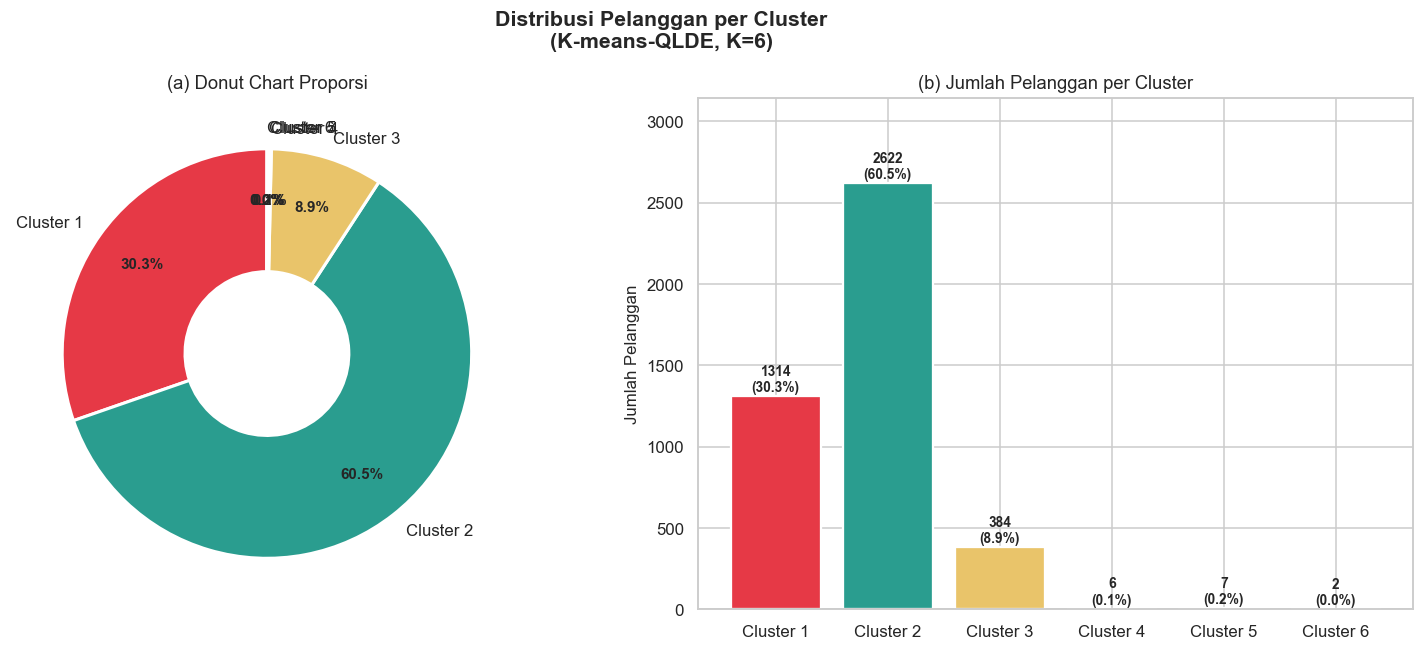

In [33]:
# ============================================================
# Visualisasi 2: Proporsi Pelanggan per Cluster
# Mereplikasi Fig 10 paper
# ============================================================
cluster_counts = pd.Series(qlde.labels_).value_counts().sort_index()
cluster_pcts   = cluster_counts / cluster_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Pelanggan per Cluster\n(K-means-QLDE, K=6)', fontsize=14, fontweight='bold')

# Pie Chart
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=[f'Cluster {c+1}' for c in cluster_counts.index],
    colors=CLUSTER_COLORS,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('(a) Donut Chart Proporsi', fontsize=12)

# Bar Chart
ax = axes[1]
bars = ax.bar(
    [f'Cluster {c+1}' for c in cluster_counts.index],
    cluster_counts.values,
    color=CLUSTER_COLORS,
    edgecolor='white', linewidth=1.5
)
for bar, cnt, pct in zip(bars, cluster_counts.values, cluster_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('(b) Jumlah Pelanggan per Cluster', fontsize=12)
ax.set_ylabel('Jumlah Pelanggan')
ax.set_ylim(0, cluster_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('../models/cluster_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Visualisasi 3D pada 3 PC Pertama (Fig 11 Paper)

Paper (Fig 11) memvisualisasikan hasil clustering pada ruang 3 principal component pertama.

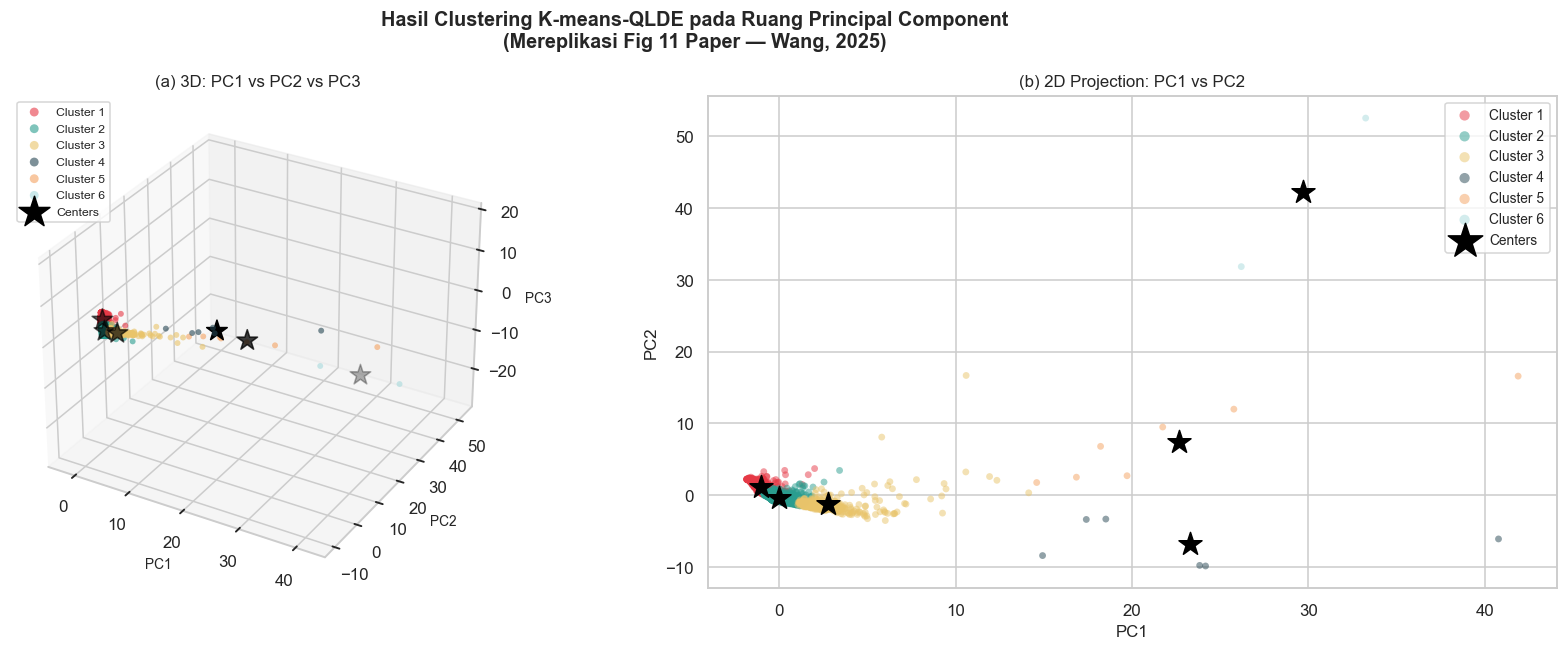

In [34]:
# ============================================================
# Visualisasi 3: Scatter Plot 3D pada PC1, PC2, PC3
# Mereplikasi Fig 11 paper
# ============================================================
labels = qlde.labels_

fig = plt.figure(figsize=(16, 6))
fig.suptitle('Hasil Clustering K-means-QLDE pada Ruang Principal Component\n'
             '(Mereplikasi Fig 11 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold')

# ── Panel 1: 3D scatter PC1 vs PC2 vs PC3 ──
ax1 = fig.add_subplot(121, projection='3d')
for c in range(K_OPTIMAL):
    mask = labels == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=15, alpha=0.6, edgecolors='none')

# Plot cluster centers
centers_2d = qlde.cluster_centers_
ax1.scatter(centers_2d[:, 0], centers_2d[:, 1], centers_2d[:, 2],
            c='black', marker='*', s=200, zorder=10, label='Centers')

ax1.set_xlabel('PC1', fontsize=9)
ax1.set_ylabel('PC2', fontsize=9)
ax1.set_zlabel('PC3', fontsize=9)
ax1.set_title('(a) 3D: PC1 vs PC2 vs PC3', fontsize=11)
ax1.legend(loc='upper left', fontsize=8, markerscale=1.5)

# ── Panel 2: 2D scatter PC1 vs PC2 ──
ax2 = fig.add_subplot(122)
for c in range(K_OPTIMAL):
    mask = labels == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=CLUSTER_COLORS[c], label=f'Cluster {c+1}',
                s=20, alpha=0.5, edgecolors='none')

ax2.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='*', s=250, zorder=10, label='Centers')

ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('(b) 2D Projection: PC1 vs PC2', fontsize=11)
ax2.legend(fontsize=9, markerscale=1.5)

plt.tight_layout()
plt.savefig('../models/cluster_3d_scatter.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.4 Analisis Cluster Centers — Radar & Bar Chart (Fig 12 Paper)

Paper (Fig 12) menampilkan *ranking* nilai cluster centers di 11 fitur untuk mengidentifikasi karakteristik tiap cluster.

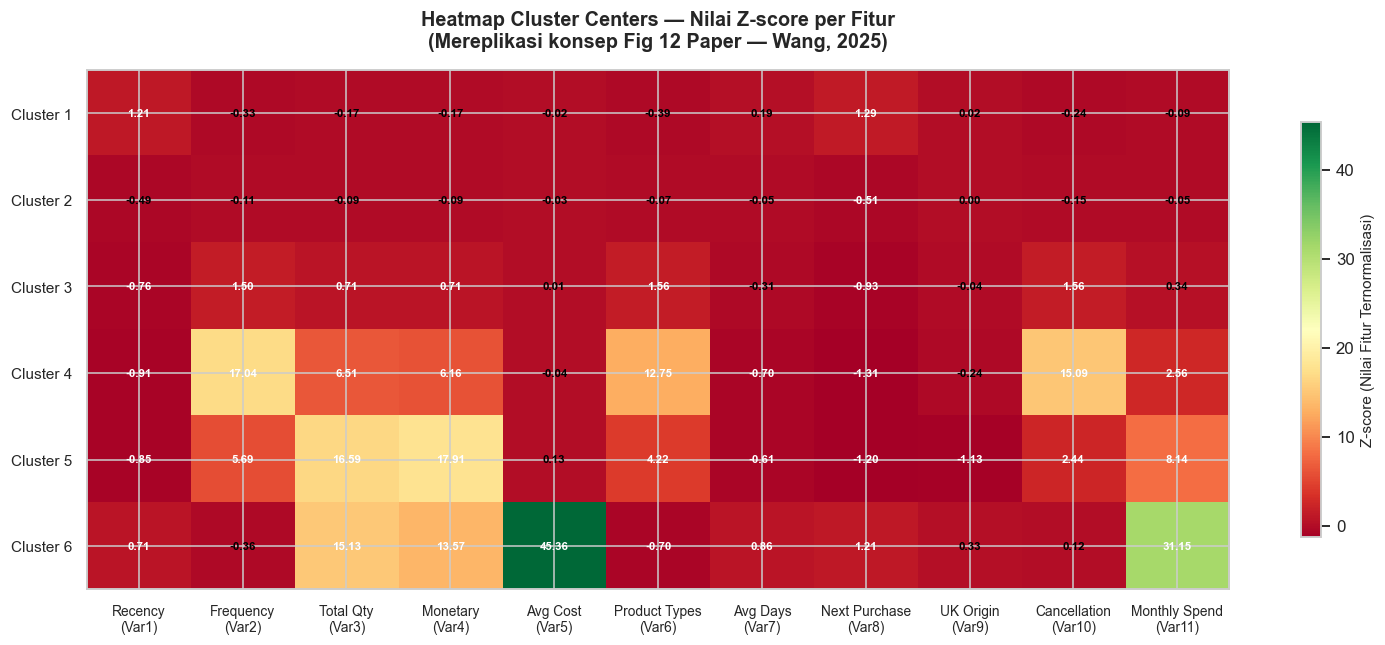


Cluster Centers (Z-score):
            Var1    Var2    Var3    Var4    Var5    Var6   Var7   Var8   Var9   Var10   Var11
Cluster 1  1.212  -0.329  -0.174  -0.166  -0.021  -0.387  0.188  1.290  0.017  -0.237  -0.092
Cluster 2 -0.492  -0.109  -0.088  -0.093  -0.026  -0.074 -0.046 -0.506  0.001  -0.151  -0.054
Cluster 3 -0.758   1.502   0.714   0.710   0.010   1.559 -0.310 -0.925 -0.044   1.562   0.335
Cluster 4 -0.910  17.037   6.510   6.158  -0.035  12.747 -0.702 -1.313 -0.238  15.087   2.562
Cluster 5 -0.851   5.693  16.587  17.912   0.127   4.219 -0.611 -1.200 -1.125   2.435   8.143
Cluster 6  0.707  -0.360  15.126  13.565  45.356  -0.697  0.861  1.213  0.327   0.115  31.145


In [35]:
# ============================================================
# Visualisasi 4: Heatmap Cluster Centers (11 fitur, Z-score)
# Mereplikasi konsep Fig 12 paper
# ============================================================

# Hitung cluster centers pada scaled data (11 fitur)
feature_cols = [f'Var{i}' for i in range(1, 12)]
feature_desc = [
    'Recency\n(Var1)', 'Frequency\n(Var2)', 'Total Qty\n(Var3)',
    'Monetary\n(Var4)', 'Avg Cost\n(Var5)', 'Product Types\n(Var6)',
    'Avg Days\n(Var7)', 'Next Purchase\n(Var8)', 'UK Origin\n(Var9)',
    'Cancellation\n(Var10)', 'Monthly Spend\n(Var11)'
]

# Cluster centers pada fitur Z-score
centers_df = df_scaled.groupby('Cluster')[feature_cols].mean()
centers_df.index = [f'Cluster {i+1}' for i in centers_df.index]

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(centers_df.values, cmap='RdYlGn', aspect='auto',
               vmin=centers_df.values.min(), vmax=centers_df.values.max())

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Z-score (Nilai Fitur Ternormalisasi)', fontsize=10)

ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_desc, fontsize=9)
ax.set_yticks(range(len(centers_df)))
ax.set_yticklabels(centers_df.index, fontsize=10)

# Nilai pada sel
for i in range(len(centers_df)):
    for j in range(len(feature_cols)):
        val = centers_df.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=color, fontweight='bold')

ax.set_title('Heatmap Cluster Centers — Nilai Z-score per Fitur\n'
             '(Mereplikasi konsep Fig 12 Paper — Wang, 2025)',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_centers_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nCluster Centers (Z-score):')
print(centers_df.round(3).to_string())

### 5.5 Radar Chart — Profil 6 Cluster

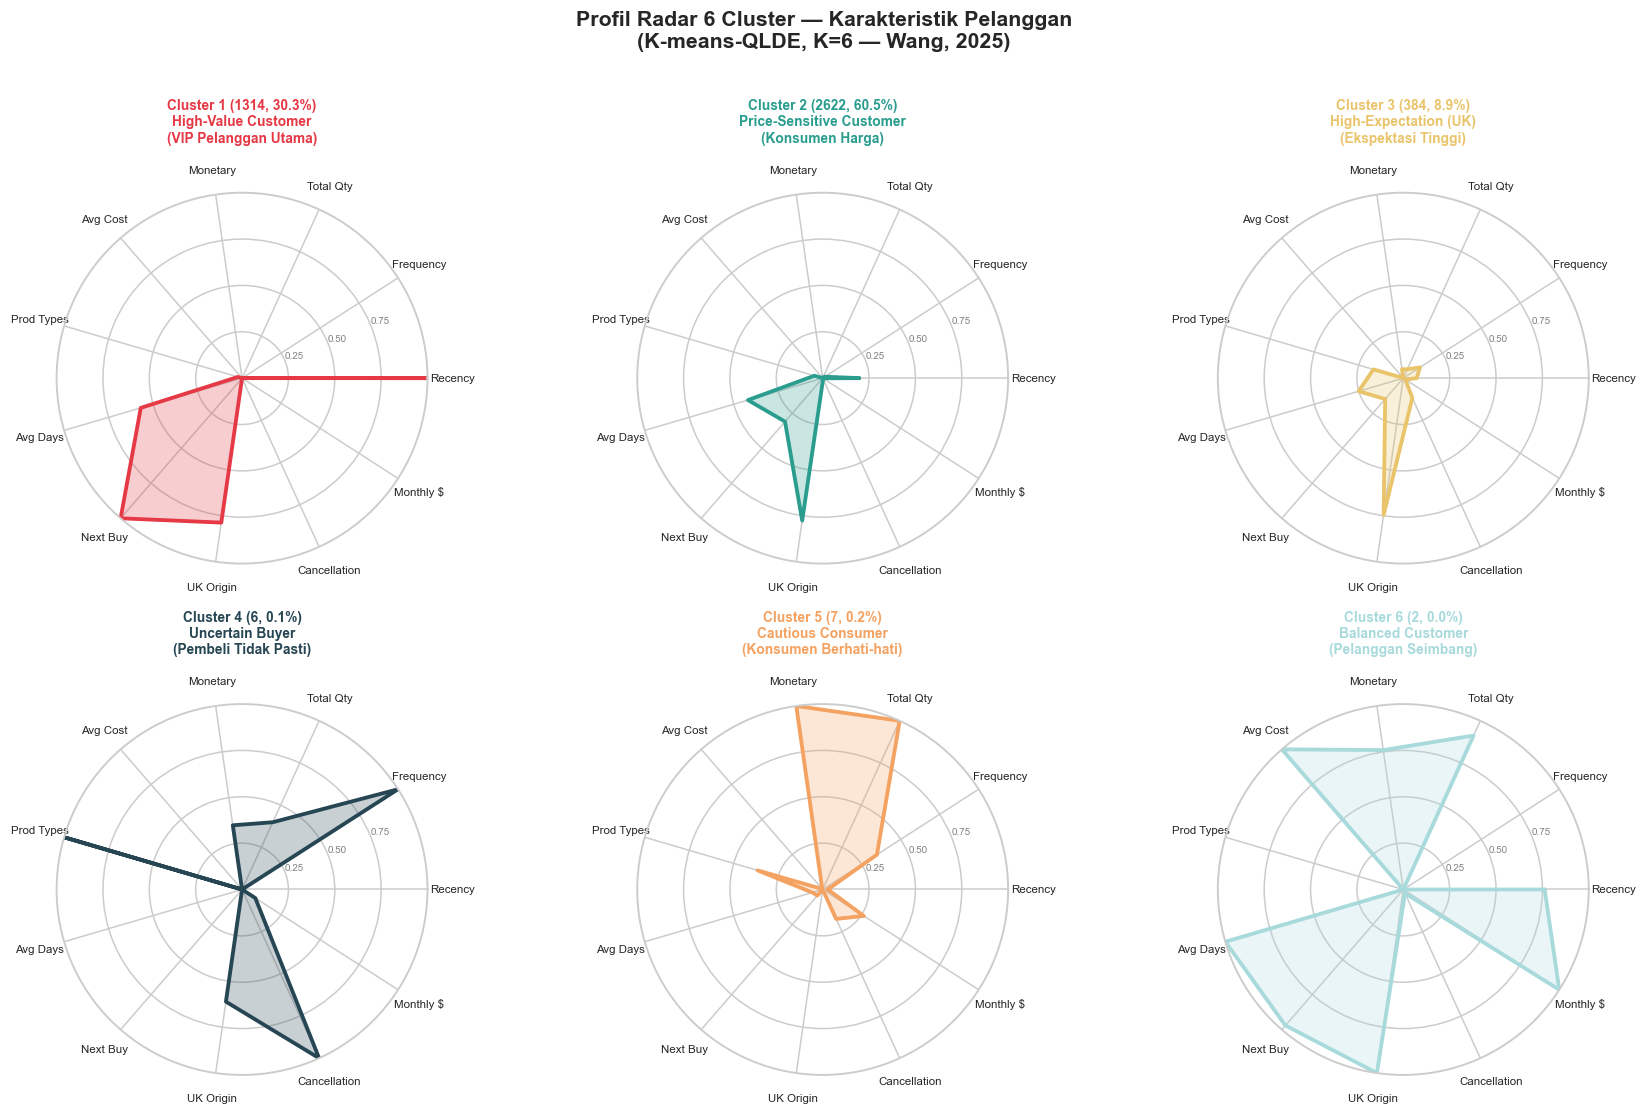

In [36]:
# ============================================================
# Visualisasi 5: Radar Chart (Spider Plot) tiap cluster
# ============================================================

# Gunakan nilai mentah (raw) ternormalisasi ke [0,1] untuk radar
centers_raw = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw.index = [f'Cluster {i+1}' for i in centers_raw.index]

# Min-max normalize cluster centers untuk tampilan radar
from sklearn.preprocessing import MinMaxScaler
scaler_mm = MinMaxScaler()
centers_norm = pd.DataFrame(
    scaler_mm.fit_transform(centers_raw.values),
    index=centers_raw.index,
    columns=feature_cols
)

# Short labels untuk radar
radar_labels = ['Recency', 'Frequency', 'Total Qty', 'Monetary', 'Avg Cost',
                'Prod Types', 'Avg Days', 'Next Buy', 'UK Origin', 'Cancellation', 'Monthly $']

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw=dict(polar=True))
fig.suptitle('Profil Radar 6 Cluster — Karakteristik Pelanggan\n'
             '(K-means-QLDE, K=6 — Wang, 2025)',
             fontsize=14, fontweight='bold', y=1.01)

cluster_profiles = [
    ('Cluster 1', 'High-Value Customer\n(VIP Pelanggan Utama)'),
    ('Cluster 2', 'Price-Sensitive Customer\n(Konsumen Harga)'),
    ('Cluster 3', 'High-Expectation (UK)\n(Ekspektasi Tinggi)'),
    ('Cluster 4', 'Uncertain Buyer\n(Pembeli Tidak Pasti)'),
    ('Cluster 5', 'Cautious Consumer\n(Konsumen Berhati-hati)'),
    ('Cluster 6', 'Balanced Customer\n(Pelanggan Seimbang)'),
]

for ax, (cname, profile), color in zip(axes.flatten(), cluster_profiles, CLUSTER_COLORS):
    values = centers_norm.loc[cname].values.tolist()
    values += values[:1]  # close the loop
    
    ax.plot(angles, values, color=color, linewidth=2.5)
    ax.fill(angles, values, color=color, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=7.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=6.5, color='gray')
    
    cnt = (df_pca['Cluster'] == int(cname.split()[-1]) - 1).sum()
    pct = cnt / len(df_pca) * 100
    ax.set_title(f'{cname} ({cnt}, {pct:.1f}%)\n{profile}',
                 fontsize=9, fontweight='bold', color=color, pad=15)

plt.tight_layout()
plt.savefig('../models/cluster_radar.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Evaluasi Kualitas Clustering (Metrik)

Mengevaluasi hasil clustering K-means-QLDE menggunakan beberapa metrik:

| Metrik | Keterangan | Ideal |
|--------|-----------|-------|
| **SSE / Inertia** | Sum of Squared Errors (Persamaan 2) | Kecil |
| **Silhouette Score** | Kohesi vs. separasi cluster | Mendekati 1 |
| **Davies-Bouldin Index** | Ratio intra-cluster vs inter-cluster distance | Kecil |
| **Calinski-Harabasz Index** | Ratio dispersi antar- vs intra-cluster | Besar |

In [37]:
# ============================================================
# Evaluasi Metrik Clustering
# ============================================================
labels = qlde.labels_

sse     = qlde.inertia_
sil     = silhouette_score(X_pca, labels)
db      = davies_bouldin_score(X_pca, labels)
ch      = calinski_harabasz_score(X_pca, labels)

print('=' * 55)
print('  EVALUASI KUALITAS CLUSTERING — K-means-QLDE (K=6)')
print('=' * 55)
print(f'  SSE (Inertia)          : {sse:>15,.2f}  ↓ (kecil = baik)')
print(f'  Silhouette Score       : {sil:>15.4f}  ↑ (kurang mendekati 1 secara teknis ,1 = baik)')
print(f'  Davies-Bouldin Index   : {db:>15.4f}  ↓ (kecil = baik)')
print(f'  Calinski-Harabasz Index: {ch:>15.2f}  ↑ (besar = baik)')
print('=' * 55)

# Simpan metrik untuk perbandingan nanti
results_qlde = {
    'Algorithm'  : 'K-means-QLDE (Paper)',
    'SSE'        : sse,
    'Silhouette' : sil,
    'Davies-Bouldin': db,
    'Calinski-Harabasz': ch,
    'K'          : K_OPTIMAL
}
print('\nHasil disimpan untuk perbandingan dengan algoritma lain.')

  EVALUASI KUALITAS CLUSTERING — K-means-QLDE (K=6)
  SSE (Inertia)          :       17,525.31  ↓ (kecil = baik)
  Silhouette Score       :          0.3550  ↑ (kurang mendekati 1 secara teknis ,1 = baik)
  Davies-Bouldin Index   :          0.9538  ↓ (kecil = baik)
  Calinski-Harabasz Index:         1297.40  ↑ (besar = baik)

Hasil disimpan untuk perbandingan dengan algoritma lain.


## 7. Analisis Karakteristik Cluster (Interpretasi Bisnis)

Menganalisis karakteristik tiap cluster berdasarkan nilai rata-rata fitur (sesuai Fig 12 dan Section 4.2 paper).

In [38]:
# ============================================================
# Analisis Karakteristik Cluster
# ============================================================
feature_desc_short = {
    'Var1'  : 'Recency (hari sejak transaksi terakhir)',
    'Var2'  : 'Frequency (jumlah transaksi)',
    'Var3'  : 'Total produk dibeli',
    'Var4'  : 'Monetary (total pengeluaran)',
    'Var5'  : 'Rata-rata biaya per transaksi',
    'Var6'  : 'Jumlah tipe produk',
    'Var7'  : 'Rata-rata hari antar pembelian',
    'Var8'  : 'Perkiraan hari pembelian berikutnya',
    'Var9'  : 'Asal UK (0/1)',
    'Var10' : 'Frekuensi pembatalan',
    'Var11' : 'Rata-rata pengeluaran bulanan',
}

centers_raw_display = df_raw.groupby('Cluster')[feature_cols].mean().round(2)
centers_raw_display.index = [f'Cluster {i+1}' for i in centers_raw_display.index]
centers_raw_display.columns = [f'{v} ({feature_desc_short[v][:25]}...)' if len(feature_desc_short[v]) > 25
                                else f'{v} ({feature_desc_short[v]})'
                                for v in feature_cols]

# Deskripsi cluster sesuai paper Section 4.2
cluster_descriptions = {
    'Cluster 1': '🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.\n'
                 '   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.',
    'Cluster 2': '💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.\n'
                 '   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.',
    'Cluster 3': '🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.\n'
                 '   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.',
    'Cluster 4': '❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.\n'
                 '   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.',
    'Cluster 5': '🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.\n'
                 '   → Banyak pertimbangan sebelum beli. Strategi: promosi akhir pekan, ulasan produk.',
    'Cluster 6': '⚖️  BALANCED CUSTOMER — Performa seimbang di semua indikator.\n'
                 '   → Tanpa preferensi ekstrem. Strategi: marketing diversifikasi.',
}

print('=' * 70)
print('  KARAKTERISTIK 6 CLUSTER — K-means-QLDE')
print('  Referensi: Section 4.2, Fig 12 — Wang (2025)')
print('=' * 70)

for c_name, desc in cluster_descriptions.items():
    c_idx = int(c_name.split()[-1]) - 1
    cnt   = (df_pca['Cluster'] == c_idx).sum()
    pct   = cnt / len(df_pca) * 100
    print(f'\n{c_name} — {cnt} pelanggan ({pct:.1f}%)')
    print(f'  {desc}')

  KARAKTERISTIK 6 CLUSTER — K-means-QLDE
  Referensi: Section 4.2, Fig 12 — Wang (2025)

Cluster 1 — 1314 pelanggan (30.3%)
  🏆 HIGH-VALUE (VIP) — Pengeluaran bulanan tinggi, produk terbanyak, cancellation rendah.
   → Kelompok terpenting bagi perusahaan (revenue terbesar). Perlu program loyalitas eksklusif.

Cluster 2 — 2622 pelanggan (60.5%)
  💰 PRICE-SENSITIVE — Volume pembelian tinggi tapi frequency & spending rendah.
   → Konsumen rasional/hemat. Strategi: promo diskon, bundle harga.

Cluster 3 — 384 pelanggan (8.9%)
  🇬🇧 HIGH-EXPECTATION (UK) — Mayoritas pelanggan UK, cancellation sedang.
   → Ekspektasi tinggi pada kualitas produk. Strategi: klarifikasi info produk.

Cluster 4 — 6 pelanggan (0.1%)
  ❓ UNCERTAIN BUYER — Cancellation tinggi, berasal dari non-UK.
   → Tidak pasti dalam keputusan pembelian. Strategi: optimalkan proses pembayaran.

Cluster 5 — 7 pelanggan (0.2%)
  🤔 CAUTIOUS CONSUMER — Recency tinggi, frekuensi rendah, berhati-hati.
   → Banyak pertimbangan sebelum b

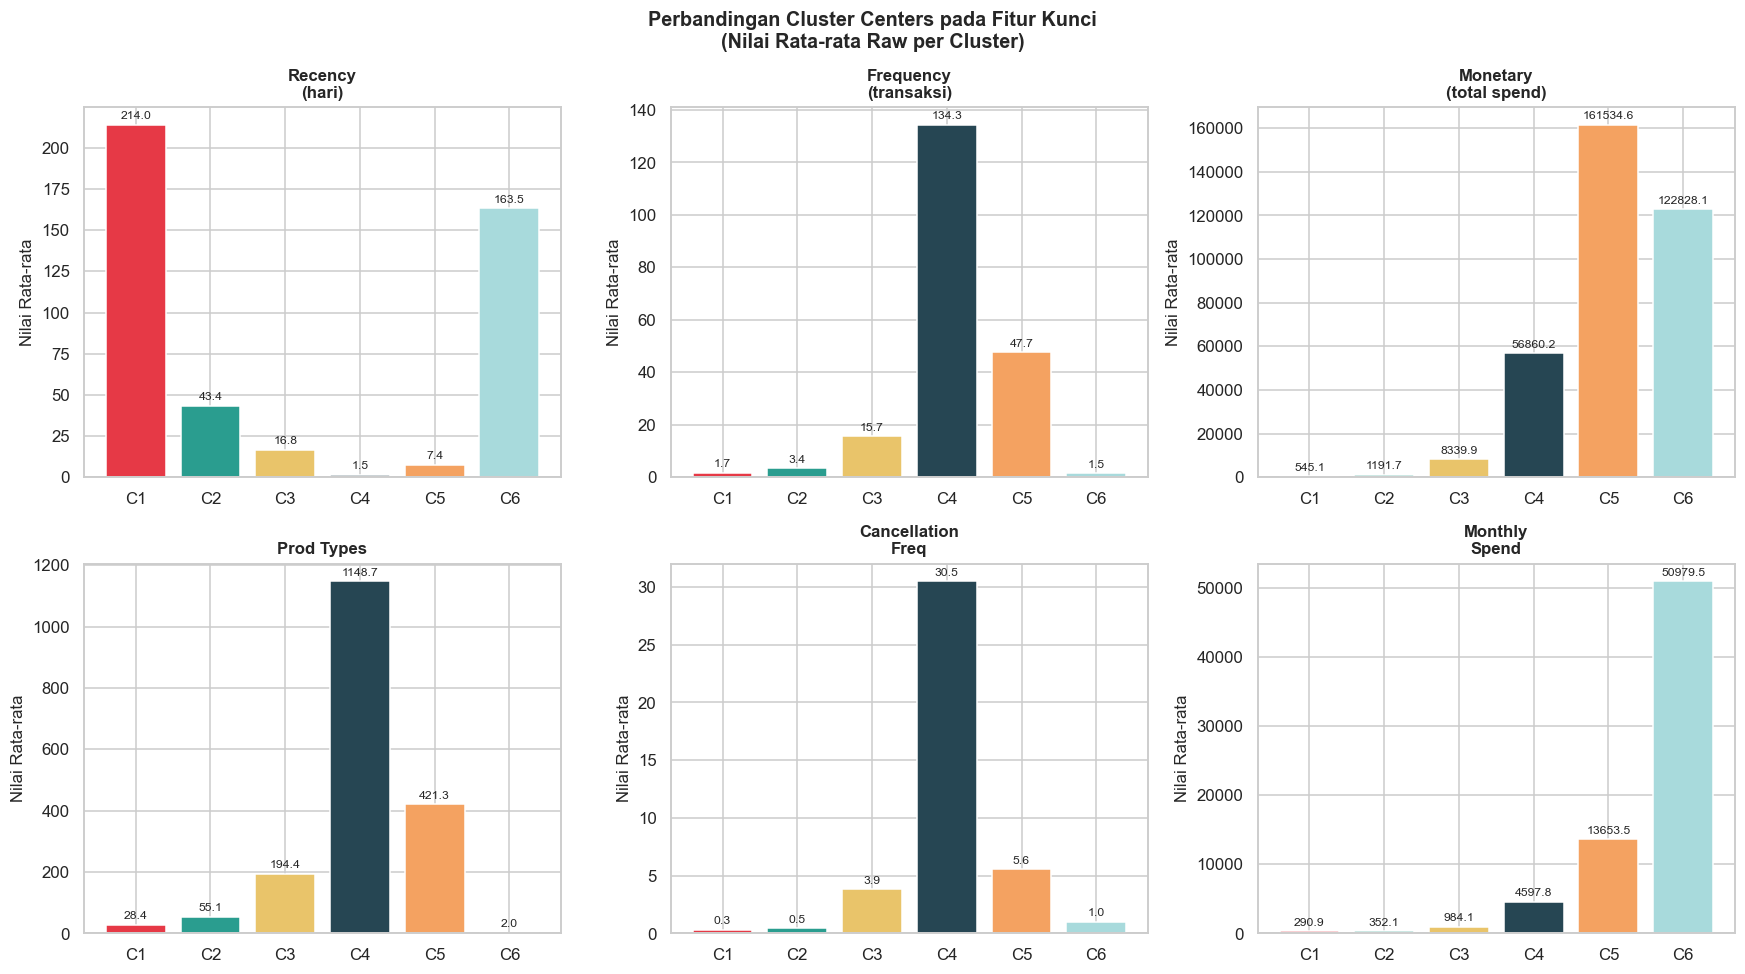

In [39]:
# ============================================================
# Visualisasi 6: Bar Chart Perbandingan Cluster Centers (Raw)
# ============================================================
centers_raw_plot = df_raw.groupby('Cluster')[feature_cols].mean()
centers_raw_plot.index = [f'Cluster {i+1}' for i in centers_raw_plot.index]

# Pilih fitur paling informatif untuk perbandingan
key_features = ['Var1', 'Var2', 'Var4', 'Var6', 'Var10', 'Var11']
key_labels   = ['Recency\n(hari)', 'Frequency\n(transaksi)', 'Monetary\n(total spend)',
                'Prod Types', 'Cancellation\nFreq', 'Monthly\nSpend']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Perbandingan Cluster Centers pada Fitur Kunci\n'
             '(Nilai Rata-rata Raw per Cluster)',
             fontsize=13, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), key_features, key_labels):
    vals = centers_raw_plot[feat].values
    bars = ax.bar(
        [f'C{i+1}' for i in range(K_OPTIMAL)],
        vals,
        color=CLUSTER_COLORS,
        edgecolor='white', linewidth=1
    )
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai Rata-rata')
    
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../models/cluster_features_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Simpan Hasil Clustering

In [40]:
# ============================================================
# Simpan Hasil Clustering
# ============================================================
import os
os.makedirs('../data/Labeled', exist_ok=True)

# Dataset berlabel
df_labeled = df_raw.copy()
df_labeled['Cluster_QLDE'] = qlde.labels_
df_labeled['Cluster_Label'] = df_labeled['Cluster_QLDE'].map({
    0: 'High-Value',
    1: 'Price-Sensitive',
    2: 'High-Expectation-UK',
    3: 'Uncertain-Buyer',
    4: 'Cautious-Consumer',
    5: 'Balanced'
})
df_labeled.to_csv('../data/Labeled/hasildata_kmeans-qlde.csv')

# Simpan metrik evaluasi
pd.DataFrame([results_qlde]).to_csv('../models/clustering_results_comparison.csv', index=False)

print('File berhasil disimpan:')
print('  → data/Labeled/customer_clustered_qlde.csv')
print('  → models/clustering_results_comparison.csv')
print()
print('Ringkasan Clustering QLDE:')
print(df_labeled['Cluster_Label'].value_counts().to_string())

File berhasil disimpan:
  → data/Labeled/customer_clustered_qlde.csv
  → models/clustering_results_comparison.csv

Ringkasan Clustering QLDE:
Cluster_Label
Price-Sensitive        2622
High-Value             1314
High-Expectation-UK     384
Cautious-Consumer         7
Uncertain-Buyer           6
Balanced                  2
